#IncodeVision
#Name of Student : Kalpesh Rajendra Patil

**IMPORT LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

**LOAD DATASET**

In [ ]:
df = pd.read_csv("/content/Messy_Employee_dataset.csv")

print("Dataset Preview:")
print(df.head())

Dataset Preview:
  Employee_ID First_Name Last_Name   Age   Department_Region    Status  \
0     EMP1000        Bob     Davis  25.0   DevOps-California    Active   
1     EMP1001        Bob     Brown   NaN       Finance-Texas    Active   
2     EMP1002      Alice     Jones   NaN        Admin-Nevada   Pending   
3     EMP1003        Eva     Davis  25.0        Admin-Nevada  Inactive   
4     EMP1004      Frank  Williams  25.0  Cloud Tech-Florida    Active   

    Join_Date     Salary                       Email       Phone  \
0    4/2/2021   59767.65       bob.davis@example.com -1651623197   
1   7/10/2020   65304.66       bob.brown@example.com -1898471390   
2   12/7/2023   88145.90     alice.jones@example.com -5596363211   
3  11/27/2021   69450.99       eva.davis@example.com -3476490784   
4    1/5/2022  109324.61  frank.williams@example.com -1586734256   

  Performance_Score  Remote_Work  
0           Average         True  
1         Excellent         True  
2              Good     

**DATA CLEANING**

In [ ]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Strip spaces from column names
df.columns = df.columns.str.strip()

# Handle missing values
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0]) # Changed for FutureWarning
    else:
        df[col] = df[col].fillna(df[col].mean()) # Changed for FutureWarning


**ENCODE CATEGORICAL DATA**

In [ ]:
# 4. ENCODE CATEGORICAL DATA
# ===============================
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

**SELECT TARGET VARIABLE**

In [ ]:
target_column = None

# Try to auto-detect "Sales" column
for col in df.columns:
    if "sale" in col.lower():
        target_column = col
        break

# If not found, use last column
if target_column is None:
    target_column = df.columns[-1]

print("Target Column:", target_column)

X = df.drop(target_column, axis=1)
y = df[target_column]

Target Column: Remote_Work


 **FEATURE SCALING**

In [ ]:
# 7. FEATURE SCALING
# ===============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


**TRAIN MODELS**

In [ ]:
# 8. TRAIN MODELS
# ===============================

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

**EVALUATION FUNCTION**

In [ ]:
# 9. EVALUATION FUNCTION
# ===============================
def evaluate(y_true, y_pred, name):
    print(f"\n{name} Performance:")
    print("R2 Score:", r2_score(y_true, y_pred))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))

**EVALUATE MODELS**

In [ ]:
# 10. EVALUATE MODELS
# ===============================
evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_dt, "Decision Tree")
evaluate(y_test, y_pred_rf, "Random Forest")


Linear Regression Performance:
R2 Score: -0.03454519835534331
MAE: 0.5056222141649985
RMSE: 0.5081717727007871

Decision Tree Performance:
R2 Score: -1.1601848286484397
MAE: 0.5392156862745098
RMSE: 0.73431307102251

Random Forest Performance:
R2 Score: -0.09759580284944147
MAE: 0.5100490196078431
RMSE: 0.5234280855899057


**VISUALIZATION**

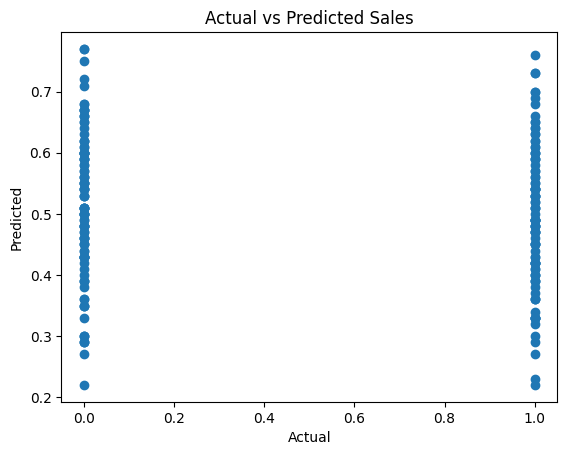

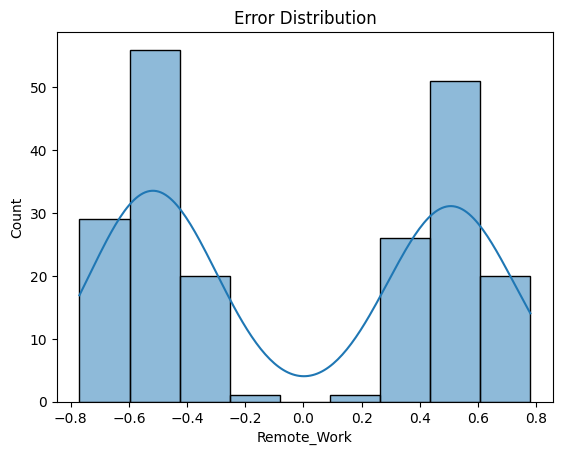

In [ ]:
# 11. VISUALIZATION
# ===============================

# Actual vs Predicted (Random Forest)
plt.figure()
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Sales")
plt.show()

# Error distribution
errors = y_test - y_pred_rf
plt.figure()
sns.histplot(errors, kde=True)
plt.title("Error Distribution")
plt.show()

**FEATURE IMPORTANCE**

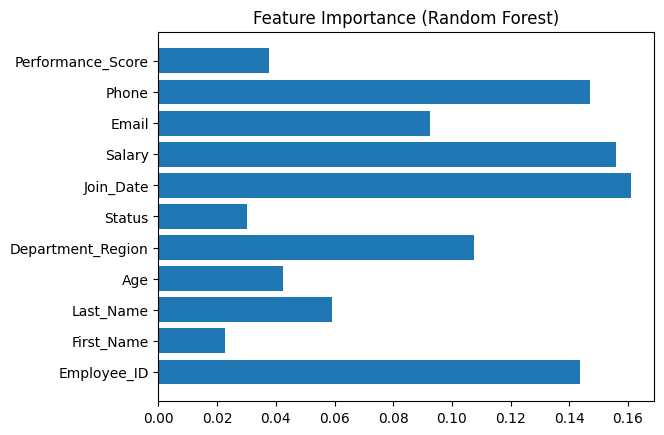

In [ ]:
# 12. FEATURE IMPORTANCE
# ===============================
importances = rf.feature_importances_
feature_names = X.columns

plt.figure()
plt.barh(feature_names, importances)
plt.title("Feature Importance (Random Forest)")
plt.show()

**SAMPLE PREDICTION**

In [ ]:
# 13. SAMPLE PREDICTION
# ===============================
sample = X.iloc[0].values.reshape(1, -1)
sample = scaler.transform(sample)

prediction = rf.predict(sample)
print("\nSample Prediction:", prediction[0])


Sample Prediction: 0.53
